In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy.abc import x, y, s
from sympy import lambdify 

# a_coeffs = ["3.4/(exp(s)+exp(-s))","-0.5*s**2+1.2",0.3,0.5]
# b_coeffs = ["2*exp(-s**2)",0.5,"1/(1+s**2)**1.5",0.05]
# a_coeffs = [1,2.5,0.2,0.2]
# b_coeffs = ["2+1e-6*s","1.5+1e-6*s","3+1e-6*s","0.5+1e-6*s"]
a_coeffs = ["1.2-0.3*s", "1-s**2", 0.02, 0.002]
b_coeffs = ["1-s**4",0.1,0.4, "0.5-0.4*s**2"]
nphi=6

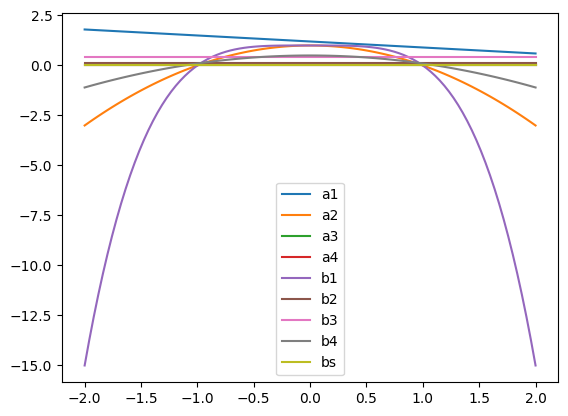

In [2]:
expansion = bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs, nphi=nphi)
expansion.plot_components()
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:181: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


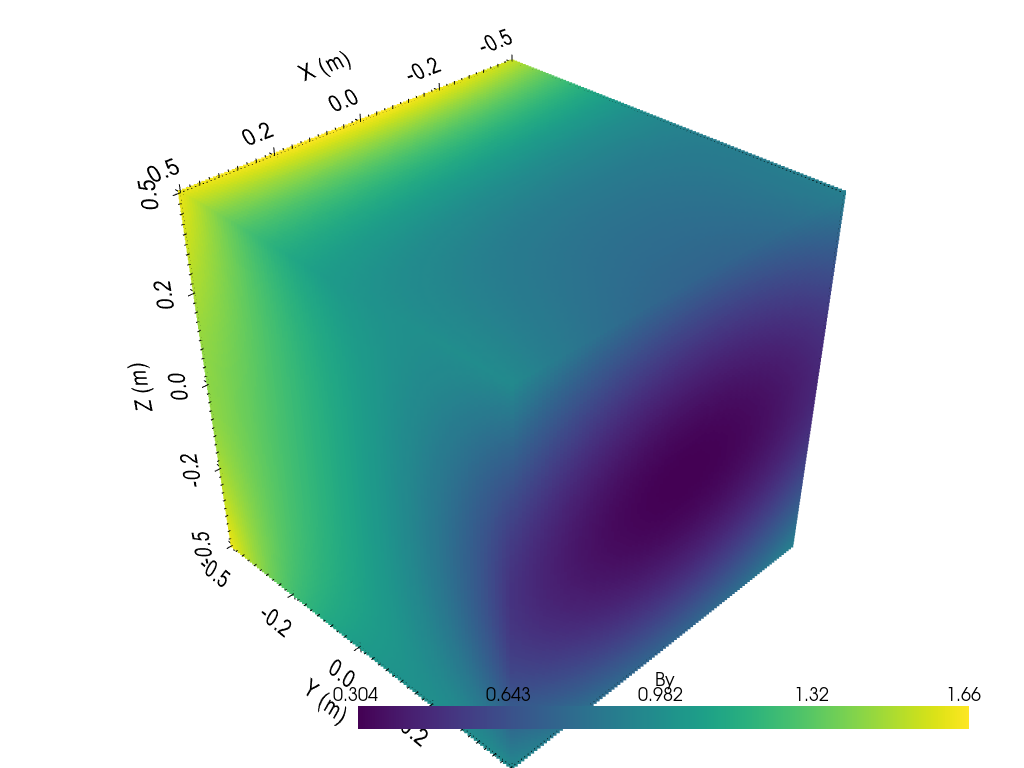

In [3]:
#make a fieldmap object
xa= np.linspace(-0.5,0.5,101)
ya=np.linspace(-0.5,0.5,101)
sa=np.linspace(-0.5,0.5,101)
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)

datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
fm.plot()


Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

In [4]:
def derivativesFromField(x, B_i, max_order): 
    ''' i= x or y, B_i is the 3d array of the field component evaluated on the grid (shape [len(x), len(y), len(s)]), max_order is the maximum order of derivative to compute'''
    dBvector=np.zeros((max_order+1, len(x), len(sa)))
    dBvector[0,:,:] = B_i[:, B_i.shape[1]//2, :] #take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 4
idx_zero = np.argmin(np.abs(xa))

dBxvector=derivativesFromField(xa, Bx_ana, max_order)
dByvector=derivativesFromField(xa, By_ana, max_order)
a_nnew=np.zeros((len(a_coeffs),len(sa)))
b_nnew=np.zeros((len(b_coeffs),len(sa)))
a_nnew[:,:]=dBxvector[:max_order,idx_zero,:]#take derivatives at x=0, keep s dependence
b_nnew[:,:]=dByvector[:max_order,idx_zero,:]

In [5]:
import timeit
t = timeit.timeit(lambda: derivativesFromField(xa, Bx_ana, max_order), number=1000)
print(t/1000)

0.0003577190610000116


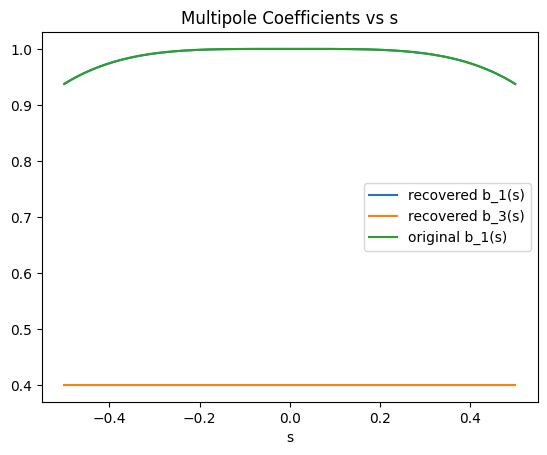

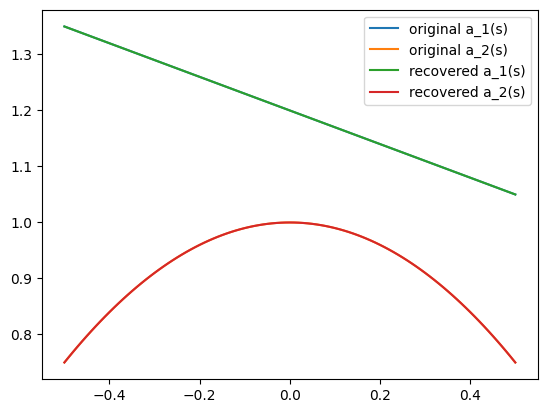

In [6]:
#evaluate the symbolic expressions of the original coefficients to compare them with the recovered ones
original_b_ana = lambdify(s, b_coeffs, 'numpy')
original_a_ana = lambdify(s, a_coeffs, 'numpy')
plt.plot(sa, b_nnew[0,:], label='recovered b_1(s)')
#plt.plot(sa, b_nnew[1,:], label='recovered b_2(s)')
#plt.plot(sa, b_nnew[2,:], label='recovered b_3(s)')
plt.plot(sa, b_nnew[2,:], label='recovered b_3(s)')

plt.plot(sa, original_b_ana(sa)[0], label='original b_1(s)')
#plt.plot(sa, original_b_ana(sa)[1], label='original b_2(s)')
#plt.plot(sa, original_b_ana(sa)[2], label='original b_3(s)')
plt.xlabel('s')
plt.legend()
plt.title('Multipole Coefficients vs s')
plt.show()

plt.plot(sa, original_a_ana(sa)[0]*np.ones_like(sa), label='original a_1(s)')
plt.plot(sa, original_a_ana(sa)[1]*np.ones_like(sa), label='original a_2(s)')
plt.plot(sa, a_nnew[0,:], label='recovered a_1(s)')
plt.plot(sa, a_nnew[1,:], label='recovered a_2(s)')
# plt.plot(sa, a_nnew[2,:], label='recovered a_3(s)')
plt.legend()
plt.show()

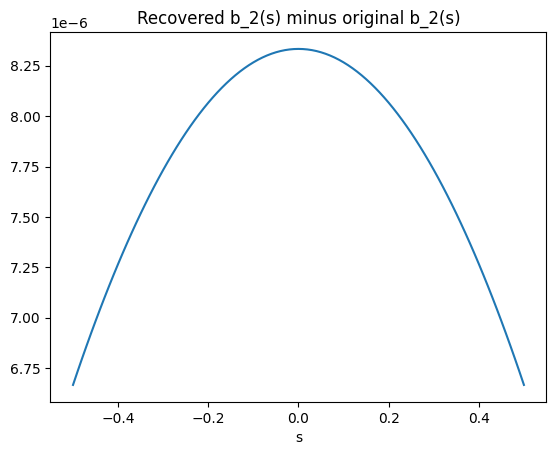

0.00010000000000000018


In [7]:
plt.plot(sa, b_nnew[1,:]-original_b_ana(sa)[1])
plt.xlabel('s')
plt.title('Recovered b_2(s) minus original b_2(s)')
plt.show() 
dx=xa[1]-xa[0]
print(dx**2)

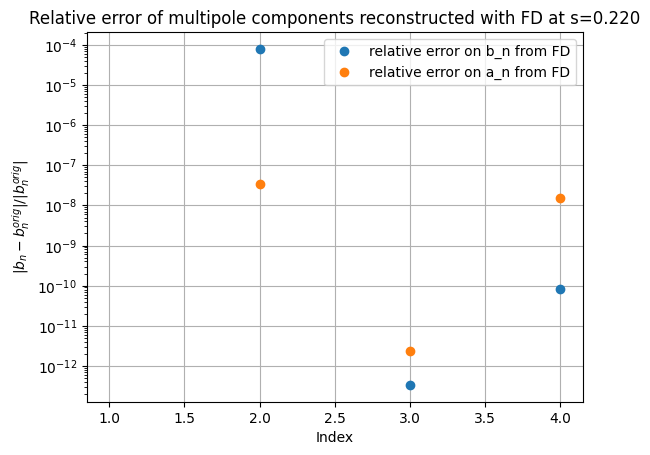

0.99765744
0.99765744


In [8]:
b_eva = lambdify(s, b_coeffs, 'numpy')
a_eva = lambdify(s, a_coeffs, 'numpy')
s_indx= 72 #s index 
s_fixed=sa[s_indx]
p=4#how many values to plot

#plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')
plt.title('Relative error of multipole components reconstructed with FD at s=' + str(f"{s_fixed:.3f}"))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-b_nnew[:p,s_indx])/b_eva(s_fixed)[:p], 'o', label='relative error on b_n from FD' )
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-a_nnew[:p,s_indx])/a_eva(s_fixed)[:p], 'o', label='relative error on a_n from FD' )
plt.legend()
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.grid(True)
plt.show()
print(b_eva(s_fixed)[0])
print(b_nnew[0,s_indx])